# **Bibliotecas**

In [1]:
import pandas as pd, numpy as np

# **Data Base**

In [2]:
df = pd.read_csv ('inmigrantes_canada.csv', sep= ',')
display (df.sample(5))
print (df.shape)

,Pais,Continente,Region,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
38,Macao,Asia,Asia Oriental,0,0,0,0,0,0,0,...,21,32,16,12,21,21,13,33,29,284
127,Nigeria,África,África Occidental,81,60,58,58,78,78,114,...,2236,2594,2375,2109,3156,3906,3103,3443,4172,39732
115,Montenegro,Europa,Sur de Europa,0,0,0,0,0,0,0,...,0,0,7,19,10,14,19,26,9,105
93,Kirguistán,Asia,Asia Central,0,0,0,0,0,0,0,...,173,161,135,168,173,157,159,278,123,2353
78,Islandia,Europa,Norte de Europa,17,33,10,9,13,6,11,...,10,2,15,13,15,30,38,42,72,570


(195, 38)


In [3]:
df.set_index ('Pais', inplace=True)
df.head(3)

,Continente,Region,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Pais,,,,,,,,,,,,,,,,,,,,,
Afganistán,Asia,Sur de Asia,16,39,39,47,71,340,496,741,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europa,Sur de Europa,1,0,0,0,0,0,1,2,...,1223,856,702,560,716,561,539,620,603,15699
Argelia,África,Norte de África,80,67,71,69,63,44,69,132,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439


In [4]:
df.reset_index (inplace=True)

Filtrar sólo los inmigrantes colombianos

In [5]:
colombia = df.query ('Pais == "Colombia"')

In [6]:
df_colombia = colombia.melt (
        value_vars = colombia.columns[3:37], \
        var_name = 'anio', \
        value_name = 'cantidad_inmigrantes')

In [7]:
df_colombia.tail()

,anio,cantidad_inmigrantes
29,2009,4652
30,2010,5218
31,2011,4366
32,2012,3741
33,2013,3631


# **Gráficas con Matplolib**

[Matplotlib:](https://matplotlib.org/)

In [8]:
import matplotlib.pyplot as plt

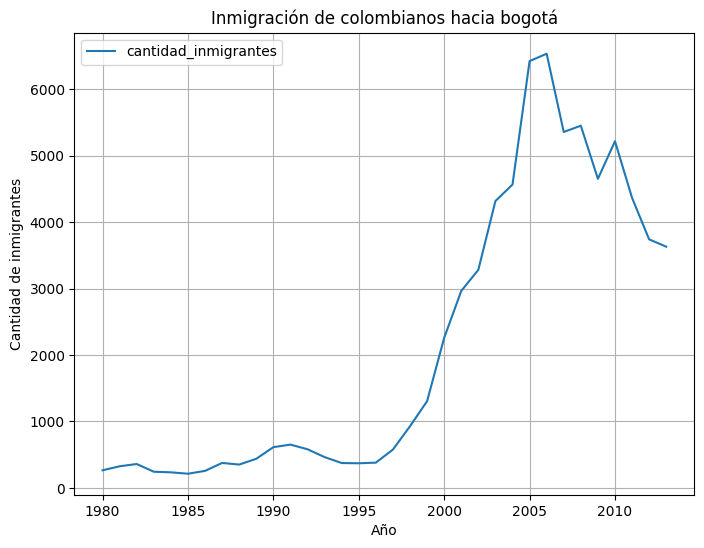

In [9]:
df_colombia.plot('anio', 'cantidad_inmigrantes', figsize= (8,6))
plt.title ('Inmigración de colombianos hacia bogotá')
plt.xlabel ('Año')
plt.ylabel ('Cantidad de inmigrantes')
plt.grid (True)

plt.show()

## **Ejercicios**

Ahora tenemos una nueva tarea: crear un gráfico de líneas comparando los números de inmigrantes de Brasil y Argentina a Canadá, los dos países más grandes de Sudamérica.

---
- *¿Hay alguna tendencia o patrón común en los datos de ambos países?*

- *¿Cuáles son los períodos con mayor número de inmigrantes en ambos países?*

In [10]:
data_final = df.melt (id_vars= df.columns[0:2], value_vars= df.columns[3:37], var_name= 'anio', value_name= 'cant_inmigrantes')
data_final.tail()

,Pais,Continente,anio,cant_inmigrantes
6625,Vietnam,Asia,2013,2112
6626,Sahara Occidental,África,2013,0
6627,Yemen,Asia,2013,217
6628,Zambia,África,2013,59
6629,Zimbabue,África,2013,407


In [11]:
df_arg_bra = data_final.query ('Pais in ["Brasil", "Argentina"]')

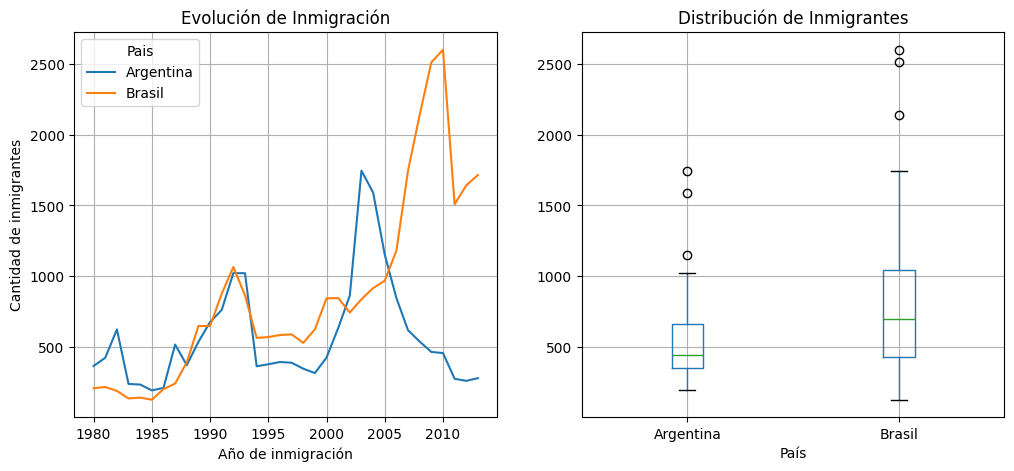

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))


df_pivot = df_arg_bra.pivot(index='anio', columns='Pais', values='cant_inmigrantes')
df_pivot.plot(ax=axs[0]) 


axs[0].set_title("Evolución de Inmigración")
axs[0].set_xlabel("Año de inmigración")
axs[0].set_ylabel("Cantidad de inmigrantes")
axs[0].grid(True)

df_pivot.boxplot(ax=axs[1])

axs[1].set_title("Distribución de Inmigrantes")
axs[1].set_xlabel("País")
axs[1].grid(True, axis='y') # Grid solo horizontal queda elegante en boxplots

plt.show()

In [13]:
# Estadística descriptiva
df_arg_bra.groupby('Pais')[['cant_inmigrantes']].describe().T.round(2)

Pais                    Argentina   Brasil
cant_inmigrantes count      34.00    34.00
                 mean      576.35   872.32
                 std       371.03   663.40
                 min       196.00   130.00
                 25%       353.25   428.25
                 50%       443.00   697.50
                 75%       667.25  1041.75
                 max      1745.00  2598.00

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

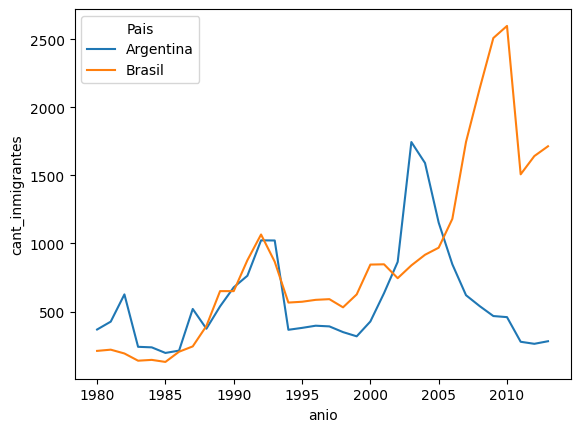

In [15]:
# Lo mismo que el código anterior con seaborn
sns.lineplot(data=df_arg_bra, x='anio', y='cant_inmigrantes', hue='Pais')
plt.gca().xaxis.set_major_locator (plt.MultipleLocator(5))

plt.show()

In [16]:
df_inmigrantes = data_final.pivot (index= 'anio', columns = 'Pais', values= 'cant_inmigrantes')

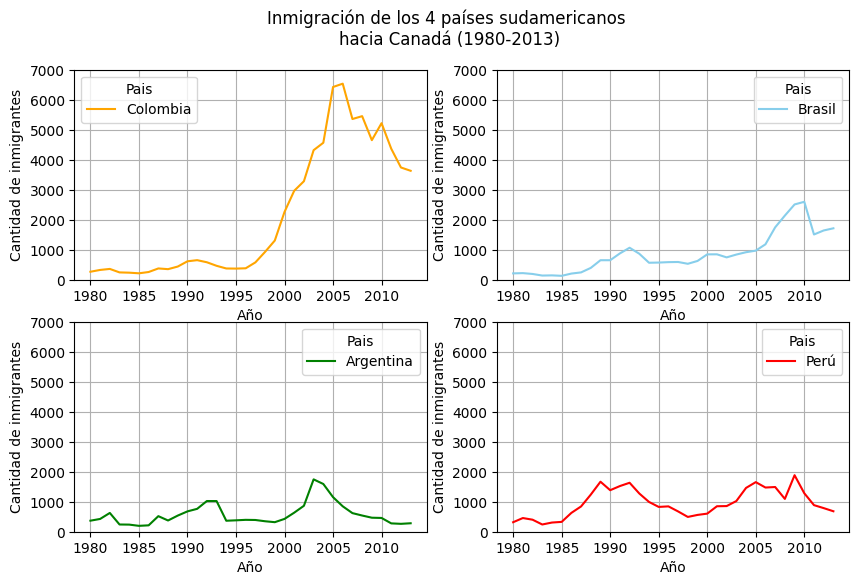

In [17]:
fig, axs = plt.subplots (2,2, figsize= (10,6)) # 2,2 significa 2 filas, 2 columnas
fig.suptitle ('Inmigración de los 4 países sudamericanos \nhacia Canadá (1980-2013)')

data_final.query('Pais =="Colombia"').pivot (
                                        index= 'anio', \
                                        columns= 'Pais', \
                                        values= 'cant_inmigrantes').plot(ax=axs[0,0], color = 'orange')

data_final.query('Pais =="Brasil"').pivot (
                                        index= 'anio', \
                                        columns= 'Pais', \
                                        values= 'cant_inmigrantes').plot(ax=axs[0,1], color= 'skyblue')

data_final.query('Pais =="Argentina"').pivot (
                                        index= 'anio', \
                                        columns= 'Pais', \
                                        values= 'cant_inmigrantes').plot(ax=axs[1,0], color= 'green')

data_final.query('Pais =="Perú"').pivot (
                                        index= 'anio', \
                                        columns= 'Pais', \
                                        values= 'cant_inmigrantes').plot(ax=axs[1,1], color= 'red')

for ax in axs.flat:
    ax.set_xlabel ('Año')
    ax.set_ylabel ('Cantidad de inmigrantes')
    ax.set_ylim (0,7000)
    ax.grid ()
    # Agregar parámetro ax.xaxis.set_major_locator(plt.MultipleLocator(n)) si los años no se agrupan



## **Empresa minorista**
---
Trabajas como Analista de Datos en una empresa minorista y te asignaron la tarea de crear una figura con subgráficos que muestre la variación en el número de ventas en cuatro tiendas diferentes a lo largo de un año. La gerencia de la empresa necesita visualizar claramente las tendencias de ventas en cada tienda, para que puedan tomar decisiones estratégicas sobre inventarios y acciones de marketing. Para ello, debes crear cuatro subgráficos dispuestos en dos filas y dos columnas, donde cada subgráfico represente una tienda diferente. En este desafío, cada subgráfico debe presentar un gráfico de líneas que muestre la variación del número de ventas a lo largo de los meses del año.

---
Para crear el DataFrame con el número de ventas de las tiendas y crear la figura, utiliza la siguiente información:

- tiendas = ['A', 'B', 'C', 'D']
- ventas_2022 = {'Ene': [100, 80, 150, 50],
    'Feb': [120, 90, 170, 60],
    'Mar': [150, 100, 200, 80],
    'Abr': [180, 110, 230, 90],
    'May': [220, 190, 350, 200],
    'Jun': [230, 150, 280, 120],
    'Jul': [250, 170, 300, 140],
    'Ago': [260, 180, 310, 150],
    'Sep': [240, 160, 290, 130],
    'Oct': [220, 140, 270, 110],
    'Nov': [400, 220, 350, 190],
    'Dec': [300, 350, 400, 250]}


In [18]:
tiendas = ['A', 'B', 'C', 'D']
ventas_2022 = {'Ene': [100, 80, 150, 50],
    'Feb': [120, 90, 170, 60],
    'Mar': [150, 100, 200, 80],
    'Abr': [180, 110, 230, 90],
    'May': [220, 190, 350, 200],
    'Jun': [230, 150, 280, 120],
    'Jul': [250, 170, 300, 140],
    'Ago': [260, 180, 310, 150],
    'Sep': [240, 160, 290, 130],
    'Oct': [220, 140, 270, 110],
    'Nov': [400, 220, 350, 190],
    'Dec': [300, 350, 400, 250]}

df_ventas = pd.DataFrame (data= ventas_2022, index= tiendas)

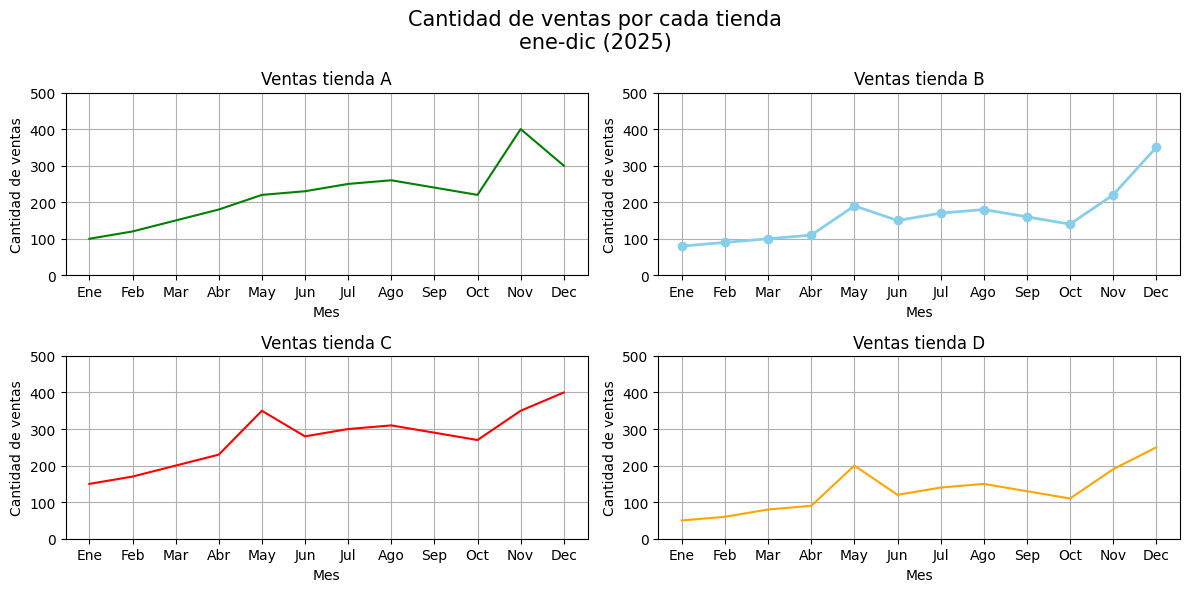

In [19]:
fig, axs = plt.subplots (2,2, figsize= (12,6))
fig.suptitle ('Cantidad de ventas por cada tienda\nene-dic (2025)', fontsize= 15)

axs[0,0].plot (df_ventas.loc ['A'], color= 'green')
axs[0,0].set_title ('Ventas tienda A')

axs[0,1].plot (df_ventas.loc ['B'], color= 'skyblue', lw=2, marker= 'o') # lw hace mas gruesa la línea, marker = 'o' marca scatter sobre esta
axs[0,1].set_title ('Ventas tienda B')

axs[1,0].plot (df_ventas.loc ['C'], color= 'red')
axs[1,0].set_title ('Ventas tienda C')

axs[1,1].plot (df_ventas.loc ['D'], color= 'orange')
axs[1,1].set_title ('Ventas tienda D')

for ax in axs.flat:
    ax.set_xlabel ('Mes')
    ax.set_ylabel ('Cantidad de ventas')
    ax.set_ylim (0,500)
    ax.grid(True)

plt.tight_layout ()
plt.show()

In [20]:
df_ventas

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dec
A,100,120,150,180,220,230,250,260,240,220,400,300
B,80,90,100,110,190,150,170,180,160,140,220,350
C,150,170,200,230,350,280,300,310,290,270,350,400
D,50,60,80,90,200,120,140,150,130,110,190,250


In [21]:
df_ventas.reset_index (inplace=True)
df_ventas.rename (columns= {'index': 'tiendas'}, inplace= True)


In [22]:
df_ventas= df_ventas.melt (id_vars='tiendas', value_vars=df_ventas.columns[1:], var_name='mes', value_name='ventas')
df_ventas.sample(5)

,tiendas,mes,ventas
42,C,Nov,350
31,D,Ago,150
36,A,Oct,220
17,B,May,190
20,A,Jun,230


In [23]:
df_ventas.groupby ('tiendas').describe().T.round(2)

tiendas            A       B       C       D
ventas count   12.00   12.00   12.00   12.00
       mean   222.50  161.67  275.00  130.83
       std     81.25   73.22   75.86   59.77
       min    100.00   80.00  150.00   50.00
       25%    172.50  107.50  222.50   87.50
       50%    225.00  155.00  285.00  125.00
       75%    252.50  182.50  320.00  160.00
       max    400.00  350.00  400.00  250.00

# **Gráficas con Seaborn**

[Seaborn:](https://seaborn.pydata.org/)

In [24]:
import seaborn as sns

In [25]:
sns.set_theme()

In [26]:
top_10 = df.sort_values('Total')[::-1].head(10)

In [27]:
def generar_grafico (palette):
    fig, ax = plt.subplots (figsize= (8,4)) #fig lienzo (todo) y ax la figura (gráfico)
    ax = sns.barplot (data= top_10, x= 'Total', y= 'Pais', hue= 'Pais', orient = 'h',
                      palette= palette, legend= False)
    ax.set (xticklabels= [])
    ax.set_facecolor ('white')
    
    ax.set_title ('Top 10 países con mayor migración hacia Canadá\n1980-2013',
                  fontsize= 14)
    ax.set_xlabel ('n° de inmigrantes')
    ax.set_ylabel ('País')
    # Agregar valores al final de cada barra
    for i, j in enumerate (top_10['Total']):
        ax.text (j+20, i, j, fontsize= 8) # j+20 termina la barra 20 posiciones a la derecha; i es índice, j es valor
    
    plt.show()

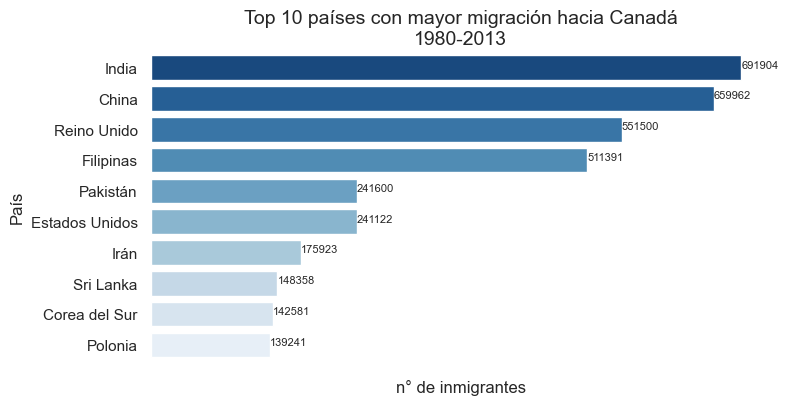

In [28]:
generar_grafico ('Blues_r') #Blues es la paleta normal, pero _r significa reversa (color intenso a menos intenso)

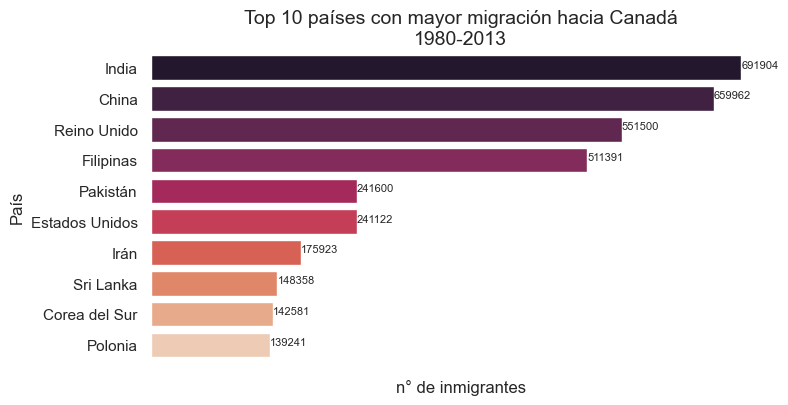

In [29]:
generar_grafico ('rocket')
# Revisar documentación de paletas en seaborn python
# Paletas: coolwarm
# Paletas categoricas: Paired, Tab10

## **Desafío:**

Crear una figura que muestre las tendencias de inmigración de los 4 mayores países de América Latina: Brasil, Argentina, Perú y Colombia. A través de esta creación, puedes explorar diversas posibilidades y mostrar de manera atractiva tu proceso de desarrollo. Y no nos olvidemos de las indicaciones. Esta figura debe tener una línea para cada país, título, etiquetas en los ejes, colores apropiados, un tema de la biblioteca Seaborn y una leyenda. Por lo tanto, piensa en cuestiones de accesibilidad, como el tamaño de las fuentes y el grosor de las líneas. Es importante elegir colores adecuados que no causen fatiga visual o dificulten la lectura de la información. Además, el tamaño de las fuentes debe ser lo suficientemente legible para que las personas puedan interpretar los datos fácilmente.

---
Consejo: para elegir la paleta de colores, se puede consultar la documentación de la biblioteca Matplotlib. Seaborn utiliza los colormaps de Matplotlib por defecto, además de ofrecer sus propias paletas de colores. Para aplicar una paleta de colores a todas las líneas de la figura, puedes usar la función sns.set_palette() y pasarle el nombre de la paleta elegida.

In [30]:
def grafico_sudamerica (palette):

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle('Países con mayor inmigración\n(1980-2013)', fontsize=16)
    
    sns.lineplot(
        data=data_final.query('Pais in ["Brasil", "Argentina", "Perú", "Colombia"]'),
        x='anio',
        y='cant_inmigrantes',
        hue='Pais',
        legend=True,
        palette=palette,
        linewidth=2.5,
        ax=axs[0]).set_facecolor ('white')
    
    axs[0].set_xlabel('Año', fontsize=12)
    axs[0].set_ylabel('Cantidad de inmigrantes', fontsize=12)
    axs[0].legend(title='País', fontsize=10)
    axs[0].grid(True, alpha=0.3)
    axs[0].xaxis.set_major_locator (plt.MultipleLocator(3))
    
    sns.boxplot(
        data=data_final.query('Pais in ["Brasil", "Argentina", "Perú", "Colombia"]'),
        x='Pais',
        y='cant_inmigrantes',
        hue= 'Pais',
        palette=palette,
        ax=axs[1])
    
    axs[1].set_xlabel('País', fontsize=12)
    axs[1].set_ylabel('Cantidad de inmigrantes', fontsize=12)
    axs[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

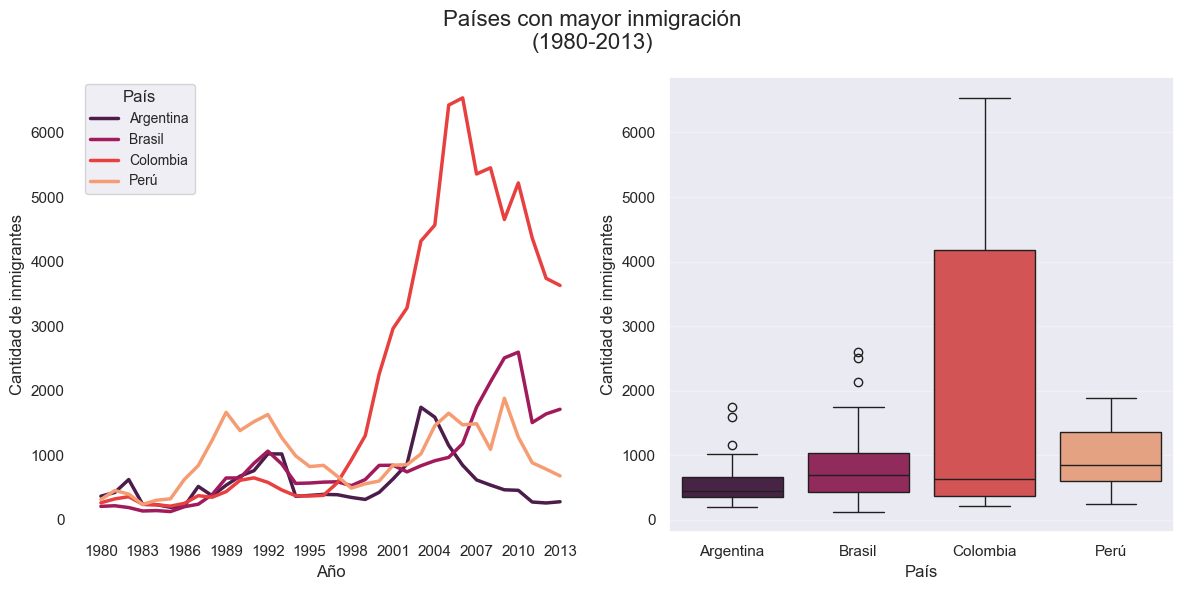

Estadística descriptiva de inmigrantes:



Pais,Argentina,Brasil,Colombia,Perú
count,34.000000,34.000000,34.000000,34.000000
mean,576.352941,872.323529,2120.235294,960.352941
std,371.025351,663.401232,2163.761316,463.154983
min,196.000000,130.000000,214.000000,241.000000
25%,353.250000,428.250000,372.000000,609.250000
50%,443.000000,697.500000,633.000000,852.000000
75%,667.250000,1041.750000,4173.750000,1358.750000
max,1745.000000,2598.000000,6535.000000,1884.000000


In [31]:
grafico_sudamerica ('rocket')
print ('Estadística descriptiva de inmigrantes:\n')
display (data_final.query ('Pais in ["Brasil", "Argentina", "Perú", "Colombia"]').groupby ('Pais')['cant_inmigrantes'].describe().T)

# **Gráficas interactivas con Plotly**

[Plotly:](https://plotly.com/python/)

In [32]:
import plotly.express as px

In [33]:
fig = px.line (data_frame= data_final.query ('Pais=="Colombia"'), x= 'anio', y= 'cant_inmigrantes')
fig.update_layout (
            width= 600,
            height= 400,
            xaxis = {'tickangle': -45},
            xaxis_title= 'año',
            yaxis_title= 'Cantidad de inmigrantes',
            title= 'Inmigración de colombianos\nhacia Canadá (1980-2013)')

fig.update_xaxes (dtick=3)
fig.update_traces (line_color= 'green', line_width= 3)

fig.show()

*Lo siguiente a realizar es eliminar las columnas de Continente y región, para dejar como índice "Pais" y transponer el DataFrame*

In [54]:
df_pyplot = df.query ('Continente == "América Latina y el Caribe"').drop (columns= ['Continente', 'Region', 'Total'], axis= 1)

In [55]:
df_pyplot = df_pyplot.set_index('Pais').T
df_pyplot.head(5)

Pais,Antigua y Barbuda,Argentina,Bahamas,Barbados,Belice,Bolivia,Brasil,Chile,Colombia,Costa Rica,...,Panamá,Paraguay,Perú,San Cristóbal y Nieves,Santa Lucía,San Vicente y las Granadinas,Surinam,Trinidad y Tobago,Uruguay,Venezuela
1980,0,368,26,372,16,44,211,1233,266,28,...,13,45,317,5,69,147,15,958,128,103
1981,0,426,23,376,27,52,220,1069,326,35,...,8,26,456,3,89,190,10,947,132,117
1982,0,626,38,299,13,42,192,1078,360,42,...,14,32,401,0,133,202,21,972,146,174
1983,0,241,12,244,21,49,139,781,244,51,...,10,40,241,16,69,154,12,766,105,124
1984,42,237,21,265,37,38,145,681,235,75,...,11,48,306,21,68,158,5,606,90,142


In [56]:
fig = px.line (
    data_frame=df_pyplot,
    x= df_pyplot.index,
    y= df_pyplot.columns,
    title= 'Inmigración hacia Canadá\n(1980-2013)',
    color= 'Pais',
    markers= True
)

fig.update_layout (
    width= 800,
    height= 400,
    xaxis= {'tickangle':-45},
    xaxis_title= 'Año',
    yaxis_title= 'N° Inmigrantes'
)

fig.write_html ('Inmigrantes_sudamericaycaribe_a_canada.html')
fig.show()

In [62]:
datos_col = data_final.query ('Pais == "Colombia"').copy()
datos_col['anio'] = datos_col['anio'].astype(int)

In [63]:
import plotly.graph_objs as go

In [64]:
fig = go.Figure()

In [67]:
import plotly.graph_objs as go

# Criando uma figura
fig = go.Figure()

# Adicionando a linha do gráfico e definindo a espessura da linha
fig.add_trace(
    go.Scatter(x=[datos_col['anio'].iloc[0]], y=[datos_col['cant_inmigrantes'].iloc[0]], mode='lines', name='cant_inmigrantes', line=dict(width=4))
)

# Definir la configuración del layout
fig.update_layout(
    title=dict(
        text='<b>Inmigración de Colombianos hacia Canadá en el periodo de 1980 a 2013</b>',
        x=0.12,
        xanchor='left',
        font=dict(size=20)
    ),
    xaxis=dict(range=[1980, 2013], autorange=False, title='<b>Año</b>'),
    yaxis=dict(range=[0, 7000], autorange=False, title='<b>Número de Inmigrantes</b>'),
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[dict(
            label='Play',
            method='animate',
            args=[None, {'frame': {'duration': 100, 'redraw': True}, 'fromcurrent': True}]
        )]
    )],
    width=1000, 
    height=500 
)

# Definir la configuración de la animación
frames = [go.Frame(data=[go.Scatter(x=datos_col['anio'].iloc[:i+1], y=datos_col['cant_inmigrantes'].iloc[:i+1])]) for i in range(len(datos_col))]
fig.frames = frames

# Mostrar la figura
fig.show()

# **Desafío**

*Tu tarea es crear un gráfico animado con Plotly que muestre estos datos. El gráfico debe tener las siguientes características:*

- Dos líneas: una para Brasil y otra para Argentina.
Un botón "Play" para iniciar la animación, mostrando el aumento o disminución del número de inmigrantes a lo largo de los años.
Las configuraciones de animación deben hacer que las dos líneas se muestren y animen al mismo tiempo.

---
***Consejos:***

- Crea un DataFrame con los datos de Argentina y no olvides dejar la columna de años como tipo int (entero).
Utiliza el código proporcionado para Brasil como base y adáptalo para incluir los datos de Argentina.
Para configurar las animaciones, puedes hacer un bucle for para recorrer el DataFrame datos_brasil y, para cada iteración, crear una nueva lista que contenga dos objetos del tipo go.Scatter, uno para cada país. Luego, cada lista puede ser utilizada para crear un objeto go.Frame, que se agrega a la lista de frames. Finalmente, la lista de frames puede ser asignada al objeto fig, que es la figura del gráfico que se animará. Con esto, cuando se inicie la animación, el gráfico mostrará las dos líneas en movimiento, una para Brasil y otra para Argentina.

<details>
<summary> Ver Respuesta</summary>

```python
import plotly.graph_objs as go

# Creando una figura
fig = go.Figure()

# Agregando la línea con los datos de Brasil
fig.add_trace(
    go.Scatter(x=[datos_brasil['Año'].iloc[0]], y=[datos_brasil['Inmigrantes'].iloc[0]], mode='lines', name='Inmigrantes de Brasil', line=dict(width=4))
)

# Agregando la línea con los datos de Argentina
fig.add_trace(
    go.Scatter(x=[datos_argentina['Año'].iloc[0]], y=[datos_argentina['Inmigrantes'].iloc[0]], mode='lines', name='Inmigrantes de Argentina', line=dict(width=4))
)

# Definiendo las configuraciones de diseño
fig.update_layout(
    title=dict(
        text='<b>Inmigración de Brasil y Argentina a Canadá en el período de 1980 a 2013</b>',
        x=0.1,
        font=dict(size=18)
    ),
    xaxis=dict(range=[1980, 2013], autorange=False, title='<b>Año</b>'),
    yaxis=dict(range=[0, 3000], autorange=False, title='<b>Número de inmigrantes</b>'),
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[dict(
            label='Play',
            method='animate',
            args=[None, {'frame': {'duration': 100, 'redraw': True}, 'fromcurrent': True}]
        )]
    )],
    width=1200,
    height=600
)

# Definiendo las configuraciones de animación
frames = []
for i in range(len(datos_brasil)):
    frame_data = [
        go.Scatter(x=datos_brasil['Año'].iloc[:i+1], y=datos_brasil['Inmigrantes'].iloc[:i+1]),
        go.Scatter(x=datos_argentina['Año'].iloc[:i+1], y=datos_argentina['Inmigrantes'].iloc[:i+1])
    ]
    frame = go.Frame(data=frame_data)
    frames.append(frame)
fig.frames = frames

# Mostrando la figura
fig.show()
\```

</details>